# 01 — Exploración inicial (NuDat 3)

**Objetivo:** conocer la estructura de los CSV originales: registros, variables, faltantes, duplicados y una primera mirada a modos / $N/Z$.

**Pregunta:** ¿cómo se relaciona la razón $N/Z$ con el modo de desintegración dominante ($\beta^-$ frente a $\beta^+$/EC) en los estados base?

**Datos:** `data/raw/` (sin modificar). Fuente: [NuDat 3](https://www.nndc.bnl.gov/nudat3/).

> Exploración solamente. Limpieza en `02_clean_etl.ipynb`. Figuras de resultados finales en `03_analysis.ipynb`.

In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path("..").resolve()
if not (ROOT / "data" / "raw").exists():
    ROOT = Path(".").resolve()
RAW = ROOT / "data" / "raw"
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 40)

## 1. Carga de los CSV canónicos

In [10]:
wallet = pd.read_csv(RAW / "walletcards.csv")
hl = pd.read_csv(RAW / "nndc_nudat_data_export (10).csv")

summary = pd.DataFrame([
    {"dataset": "walletcards", "n_filas": len(wallet), "n_columnas": wallet.shape[1]},
    {"dataset": "export_10_halflife", "n_filas": len(hl), "n_columnas": hl.shape[1]},
])
summary

,dataset,n_filas,n_columnas
0,walletcards,4116,25
1,export_10_halflife,3150,3


### Interpretación

- **Wallet Cards** incluye estados base e isómeros (`Level Index`).
- El export Chart aporta $t_{1/2}$ ya en segundos para el join $(Z,N)$.

## 2. Estructura y tipos

In [11]:
def describe_structure(name, df):
    print("=" * 72)
    print(name)
    print(df.dtypes)
    print("shape:", df.shape)
    display(df.head(3))

describe_structure("walletcards", wallet)
describe_structure("halflife chart", hl)

walletcards
Atomic Number (Z)            int64
Atomic Mass (A)              int64
Level Index                  int64
Element                        str
Level Energy (Modifier)    float64
Level Energy               float64
Level Energy (Unit)            str
Level Energy (Error)       float64
Spin-Parity                    str
Half-Life (Modifier)           str
Half-Life                      str
Half-Life (Unit)               str
Half-Life (Error)              str
Decay Width (Modifier)     float64
Decay Width                float64
Decay Width (Unit)             str
Decay Width (Error)            str
Abundance (Modifier)       float64
Abundance                  float64
Abundance (Error)          float64
Mass Excess                float64
Mass Excess (Unit)             str
Mass Excess (Error)        float64
Decay Modes                    str
Unnamed: 24                float64
dtype: object
shape: (4116, 25)


,Atomic Number (Z),Atomic Mass (A),Level Index,Element,Level Energy (Modifier),Level Energy,Level Energy (Unit),Level Energy (Error),Spin-Parity,Half-Life (Modifier),Half-Life,Half-Life (Unit),Half-Life (Error),Decay Width (Modifier),Decay Width,Decay Width (Unit),Decay Width (Error),Abundance (Modifier),Abundance,Abundance (Error),Mass Excess,Mass Excess (Unit),Mass Excess (Error),Decay Modes,Unnamed: 24
0,0,1,0,NN,NaN,0.0,keV,NaN,1/2+,NaN,608.9,s,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8071.318060,keV,0.000440,B- = 100,NaN
1,1,1,0,H,NaN,0.0,keV,NaN,1/2+,NaN,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.9855,NaN,7288.971064,keV,0.000013,NaN,NaN
2,1,2,0,H,NaN,0.0,keV,NaN,1+,NaN,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0145,NaN,13135.722895,keV,0.000015,NaN,NaN


halflife chart
z                    int64
n                    int64
halflife(Seconds)      str
dtype: object
shape: (3150, 3)


,z,n,halflife(Seconds)
0,1,0,STABLE
1,1,1,STABLE
2,2,1,STABLE


## 3. Valores faltantes

In [12]:
def missing_report(df):
    miss = df.isna().sum()
    return pd.DataFrame({"n_na": miss, "pct": (100 * miss / len(df)).round(2)}).query("n_na > 0").sort_values("n_na", ascending=False)

display(missing_report(wallet))
display(missing_report(hl))

,n_na,pct
Level Energy (Modifier),4116,100.00
Abundance (Modifier),4116,100.00
Decay Width (Modifier),4116,100.00
Unnamed: 24,4116,100.00
Half-Life (Modifier),4100,99.61
Decay Width (Error),4086,99.27
Decay Width,4079,99.10
Decay Width (Unit),4079,99.10
Abundance (Error),3857,93.71
Abundance,3828,93.00


,n_na,pct


### Interpretación

Faltantes en vida media o modos suelen corresponder a resonancias (decay width) o estados poco conocidos. El Chart half-life no cubre todos los $(Z,N)$ del Wallet: en limpieza se completa con Wallet cuando hace falta.

## 4. Duplicados

In [13]:
print("Wallet duplicados (Z, A, Level Index):",
      wallet.duplicated(["Atomic Number (Z)", "Atomic Mass (A)", "Level Index"]).sum())
print("Chart HL duplicados (z, n):", hl.duplicated(["z", "n"]).sum())

Wallet duplicados (Z, A, Level Index): 0
Chart HL duplicados (z, n): 0


## 5. Rangos

In [14]:
print("Z wallet:", wallet["Atomic Number (Z)"].min(), "→", wallet["Atomic Number (Z)"].max())
print("A wallet:", wallet["Atomic Mass (A)"].min(), "→", wallet["Atomic Mass (A)"].max())
print("hl filas:", len(hl), "| Z:", hl["z"].min(), "→", hl["z"].max())

Z wallet: 0 → 118
A wallet: 1 → 294
hl filas: 3150 | Z: 1 → 118


## 6. Modos de decaimiento (variable clave)

mode_rough
B-        1402
EC/B+      898
ALPHA      618
STABLE     253
OTHER      200
Name: count, dtype: int64

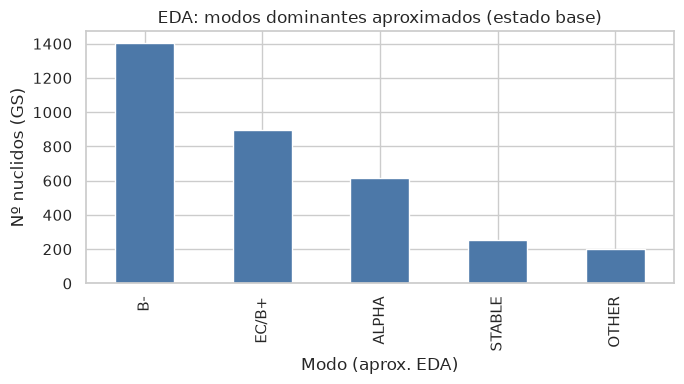

In [15]:
gs = wallet[wallet["Level Index"] == 0].copy()
gs["N"] = gs["Atomic Mass (A)"] - gs["Atomic Number (Z)"]
gs["N_over_Z"] = gs["N"] / gs["Atomic Number (Z)"].replace(0, np.nan)
gs["is_stable"] = gs["Half-Life"].astype(str).str.upper().eq("STABLE")

def rough_mode(raw, stable):
    if stable:
        return "STABLE"
    if pd.isna(raw) or str(raw).strip() == "":
        return "MISSING"
    first = str(raw).split(",")[0]
    m = re.match(r"^(.+?)\s*(?:=|~)", first)
    tok = (m.group(1) if m else first).strip().upper()
    if tok.startswith("B-"):
        return "B-"
    if tok.startswith("EC") or tok.startswith("B+"):
        return "EC/B+"
    if tok.startswith("A") or tok in {"Α", "ALPHA"}:
        return "ALPHA"
    if tok.startswith("IT"):
        return "IT"
    return "OTHER"

gs["mode_rough"] = [rough_mode(r, s) for r, s in zip(gs["Decay Modes"], gs["is_stable"])]
vc = gs["mode_rough"].value_counts()
display(vc)

fig, ax = plt.subplots(figsize=(7, 4))
vc.plot(kind="bar", ax=ax, color="#4c78a8")
ax.set_xlabel("Modo (aprox. EDA)"); ax.set_ylabel("Nº nuclidos (GS)")
ax.set_title("EDA: modos dominantes aproximados (estado base)")
plt.tight_layout()
plt.savefig(FIG / "eda_modos_dominantes.png", dpi=120)
plt.show()

### Interpretación

Dominan $\beta^-$ y EC/$\beta^+$. Los estables son una franja estrecha. El parseo fino (branching, clases `EC_BP`, etc.) se hace en la limpieza.

## 7. Primera mirada a $N/Z$ por modo

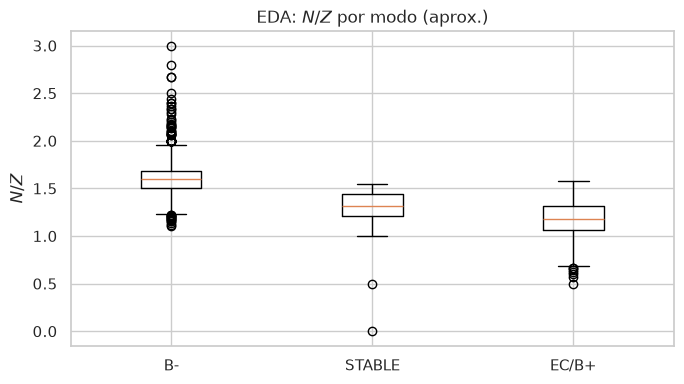

B-: n=1401  mean=1.605
STABLE: n=253  mean=1.306
EC/B+: n=898  mean=1.176


In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ["B-", "STABLE", "EC/B+"]
data = [gs.loc[gs["mode_rough"] == m, "N_over_Z"].dropna() for m in order]
ax.boxplot(data, tick_labels=order)
ax.set_ylabel("$N/Z$"); ax.set_title("EDA: $N/Z$ por modo (aprox.)")
plt.tight_layout()
plt.show()
for m, s in zip(order, data):
    print(f"{m}: n={len(s)}  mean={s.mean():.3f}")

### Interpretación

Ya se intuye la separación: $\langle N/Z\rangle$ de $\beta^-$ por encima de EC/$\beta^+$, con estables en medio. **Chart, frontera por $Z$ e histograma** se calculan con SQL en `03_analysis.ipynb` (figuras canónicas del proyecto).

## 8. Decisiones para la limpieza

| Hallazgo | Acción |
|----------|--------|
| Unidades mixtas de $t_{1/2}$ | Convertir a segundos; `STABLE` → flag |
| Chart HL sin cubrir todo Wallet | Preferir Chart en GS; si no, Wallet |
| Resonancias (decay width) | Marcar `is_resonance` |
| Isómeros | Análisis N/Z–modo en `Level Index = 0` |

## 9. Conclusiones

1. Dos CSV canónicos bastan para la pregunta: Wallet (modos/estados) + Chart half-life.
2. La separación $\beta^-$ / EC+$\beta^+$ según $N/Z$ ya se perfila en EDA.
3. Siguiente etapa: limpieza reproducible → `data/processed/` (`02_clean_etl.ipynb`).